# Malaria Prediction in Sub-Saharan Africa
**Author:** Afriyie Karikari Bempah, PharmD  
**Data:** WHO GHO API + World Bank API (live data)  
**Tools:** Python, requests, pandas, scikit-learn, matplotlib

---

### Research Question
Can socioeconomic and health system variables predict malaria incidence across African countries — and which factors matter most?

### Approach
1. Pull malaria incidence from WHO and socioeconomic indicators from World Bank
2. Exploratory analysis — who bears the highest burden and why?
3. Compare Linear Regression, Ridge Regression, and Random Forest
4. Hyperparameter tuning and model evaluation
5. Country-level 2023 predictions vs actuals

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Pull Data from WHO and World Bank APIs

In [2]:
# malaria incidence from WHO
url_malaria = "https://ghoapi.azureedge.net/api/MALARIA_EST_INCIDENCE"
df_malaria = pd.DataFrame(requests.get(url_malaria).json()['value'])

df_malaria_africa = df_malaria[
    df_malaria['ParentLocation'] == 'Africa'
][['SpatialDim', 'TimeDim', 'NumericValue']].copy()
df_malaria_africa.columns = ['Country_Code', 'Year', 'Malaria_Incidence']
df_malaria_africa = df_malaria_africa.dropna(subset=['Malaria_Incidence'])

# country names
url_countries = "https://ghoapi.azureedge.net/api/DIMENSION/COUNTRY/DimensionValues"
df_countries = pd.DataFrame(requests.get(url_countries).json()['value'])[['Code','Title']]
df_countries.columns = ['Country_Code', 'Country_Name']

# World Bank indicators
africa_codes = df_malaria_africa['Country_Code'].unique().tolist()
africa_codes_str = ';'.join(africa_codes)

indicators = {
    'NY.GDP.PCAP.CD': 'GDP_Per_Capita',
    'SP.RUR.TOTL.ZS': 'Rural_Population_Pct',
    'SH.XPD.CHEX.GD.ZS': 'Health_Expenditure_GDP_Pct'
}

dfs = []
for code, name in indicators.items():
    url_wb = (f"https://api.worldbank.org/v2/country/{africa_codes_str}"
              f"/indicator/{code}?format=json&per_page=2000&mrv=25")
    data_wb = requests.get(url_wb).json()
    if len(data_wb) > 1 and data_wb[1]:
        df_temp = pd.DataFrame(data_wb[1])[['countryiso3code','date','value']].copy()
        df_temp.columns = ['Country_Code', 'Year', name]
        df_temp['Year'] = df_temp['Year'].astype(int)
        df_temp = df_temp.dropna(subset=[name])
        dfs.append(df_temp)
        print(f"✓ {name}: {len(df_temp):,} records")

# merge all
df = df_malaria_africa.copy()
for df_ind in dfs:
    df = df.merge(df_ind, on=['Country_Code','Year'], how='left')
df = df.merge(df_countries, on='Country_Code', how='left')
df_clean = df.dropna()

print(f"\nFinal dataset: {df_clean.shape}")
print(f"Countries: {df_clean['Country_Code'].nunique()}")
print(f"Year range: {df_clean['Year'].min()} to {df_clean['Year'].max()}")

✓ GDP_Per_Capita: 1,095 records
✓ Rural_Population_Pct: 1,125 records
✓ Health_Expenditure_GDP_Pct: 1,053 records

Final dataset: (1011, 7)
Countries: 44
Year range: 2000 to 2023


## 2. Summary Statistics

In [3]:
print("Dataset Summary:")
print(df_clean[['Malaria_Incidence','GDP_Per_Capita',
                'Rural_Population_Pct','Health_Expenditure_GDP_Pct']].describe().round(2))

latest = df_clean[df_clean['Year'] == df_clean['Year'].max()]
print(f"\nTop 5 highest burden countries ({latest['Year'].iloc[0]}):")
print(latest.nlargest(5,'Malaria_Incidence')[
    ['Country_Name','Malaria_Incidence']].to_string())
print(f"\nTop 5 lowest burden countries ({latest['Year'].iloc[0]}):")
print(latest.nsmallest(5,'Malaria_Incidence')[
    ['Country_Name','Malaria_Incidence']].to_string())

Dataset Summary:
       Malaria_Incidence  GDP_Per_Capita  Rural_Population_Pct  \
count            1011.00         1011.00               1011.00   
mean              225.26         1834.46                 58.87   
std               158.84         2284.13                 17.37   
min                 0.00          109.59                  8.36   
25%                66.20          528.42                 46.37   
50%               243.25          936.64                 60.28   
75%               357.35         2013.75                 72.26   
max               711.44        18210.56                 91.96   

       Health_Expenditure_GDP_Pct  
count                     1011.00  
mean                         5.02  
std                          2.10  
min                          1.22  
25%                          3.57  
50%                          4.52  
75%                          6.07  
max                         15.12  

Top 5 highest burden countries (2023):
                        

## 3. Exploratory Data Analysis

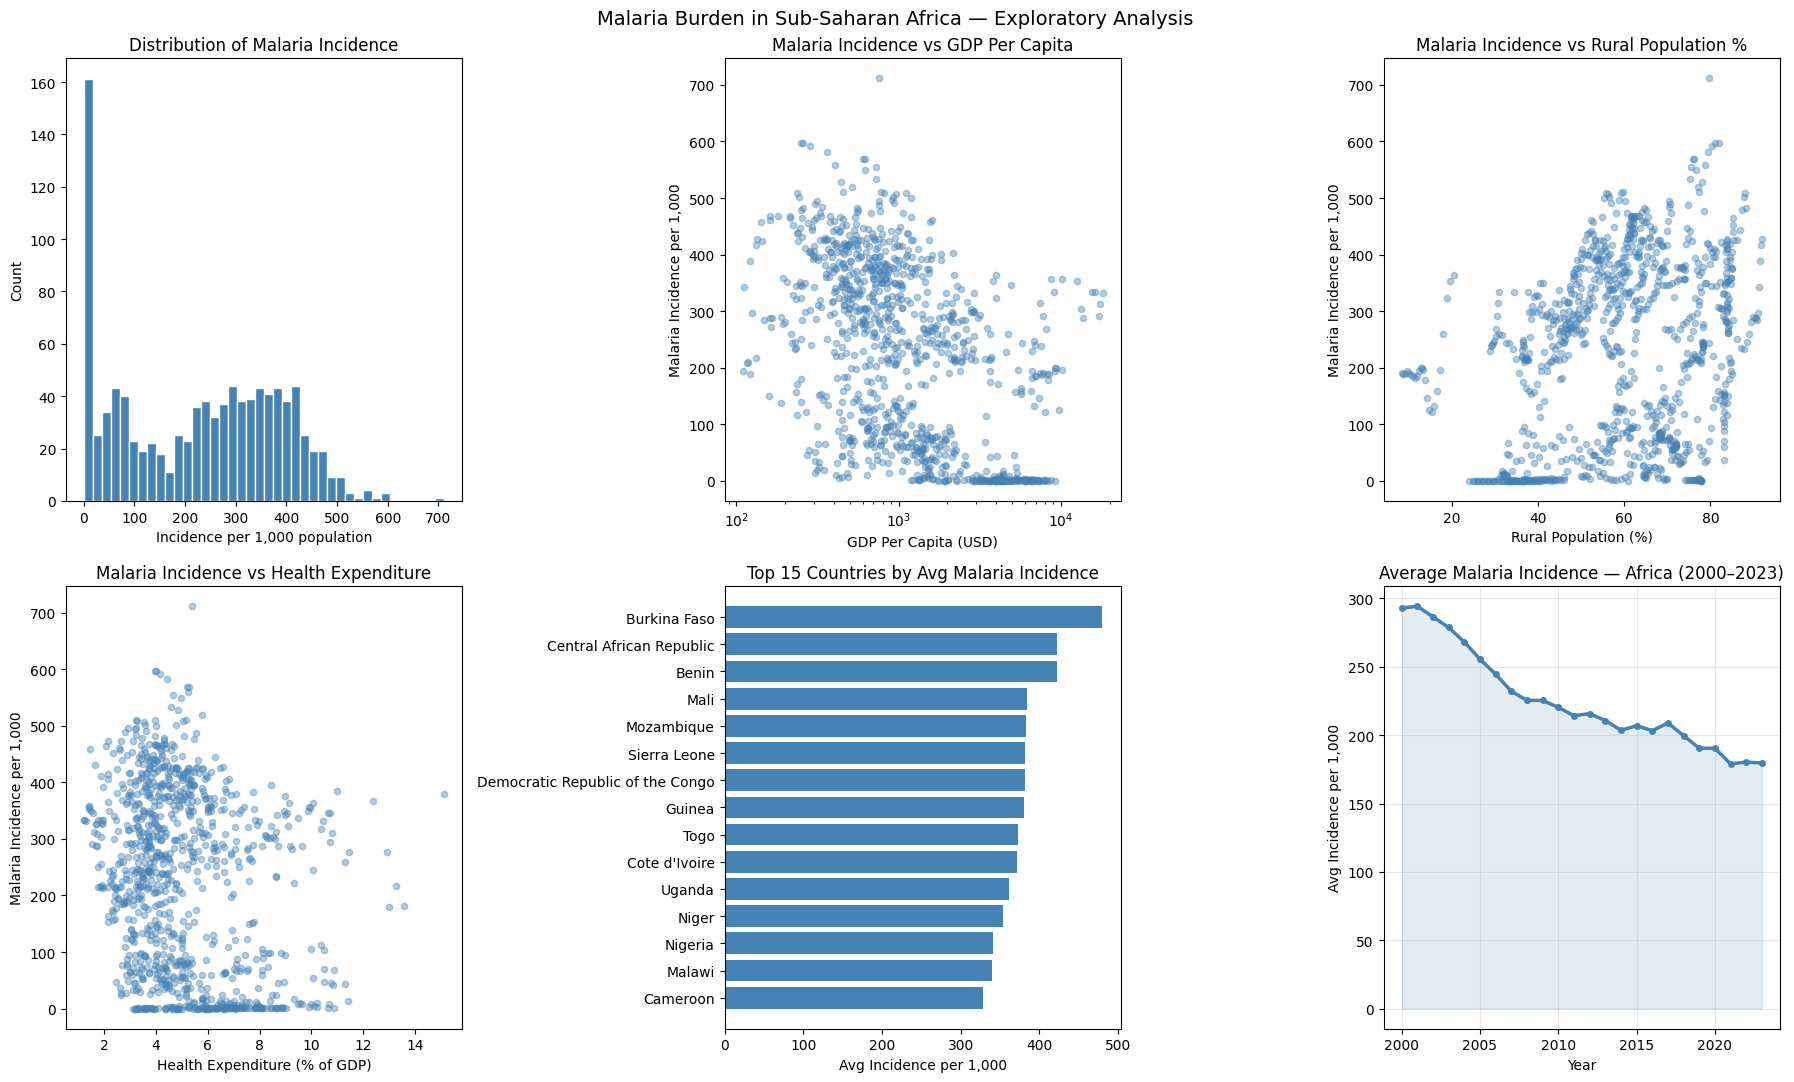

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

axes[0,0].hist(df_clean['Malaria_Incidence'], bins=40,
               color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution of Malaria Incidence')
axes[0,0].set_xlabel('Incidence per 1,000 population')
axes[0,0].set_ylabel('Count')

axes[0,1].scatter(df_clean['GDP_Per_Capita'], df_clean['Malaria_Incidence'],
                  alpha=0.4, color='steelblue', s=20)
axes[0,1].set_title('Malaria Incidence vs GDP Per Capita')
axes[0,1].set_xlabel('GDP Per Capita (USD)')
axes[0,1].set_ylabel('Malaria Incidence per 1,000')
axes[0,1].set_xscale('log')

axes[0,2].scatter(df_clean['Rural_Population_Pct'], df_clean['Malaria_Incidence'],
                  alpha=0.4, color='steelblue', s=20)
axes[0,2].set_title('Malaria Incidence vs Rural Population %')
axes[0,2].set_xlabel('Rural Population (%)')
axes[0,2].set_ylabel('Malaria Incidence per 1,000')

axes[1,0].scatter(df_clean['Health_Expenditure_GDP_Pct'], df_clean['Malaria_Incidence'],
                  alpha=0.4, color='steelblue', s=20)
axes[1,0].set_title('Malaria Incidence vs Health Expenditure')
axes[1,0].set_xlabel('Health Expenditure (% of GDP)')
axes[1,0].set_ylabel('Malaria Incidence per 1,000')

top15 = df_clean.groupby('Country_Name')['Malaria_Incidence'].mean()                .sort_values(ascending=False).head(15)
axes[1,1].barh(top15.index, top15.values, color='steelblue')
axes[1,1].set_title('Top 15 Countries by Avg Malaria Incidence')
axes[1,1].set_xlabel('Avg Incidence per 1,000')
axes[1,1].invert_yaxis()

yearly = df_clean.groupby('Year')['Malaria_Incidence'].mean()
axes[1,2].plot(yearly.index, yearly.values,
               color='steelblue', linewidth=2.5, marker='o', markersize=4)
axes[1,2].fill_between(yearly.index, yearly.values, alpha=0.15, color='steelblue')
axes[1,2].set_title('Average Malaria Incidence — Africa (2000–2023)')
axes[1,2].set_xlabel('Year')
axes[1,2].set_ylabel('Avg Incidence per 1,000')
axes[1,2].grid(alpha=0.3)

plt.suptitle('Malaria Burden in Sub-Saharan Africa — Exploratory Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('chart1_eda.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Malaria incidence has fallen 40% across Africa since 2000.
# GDP per capita shows the strongest inverse relationship with malaria burden
# confirming poverty as the primary structural driver of malaria risk.

## 4. Correlation Analysis & Log Transformation

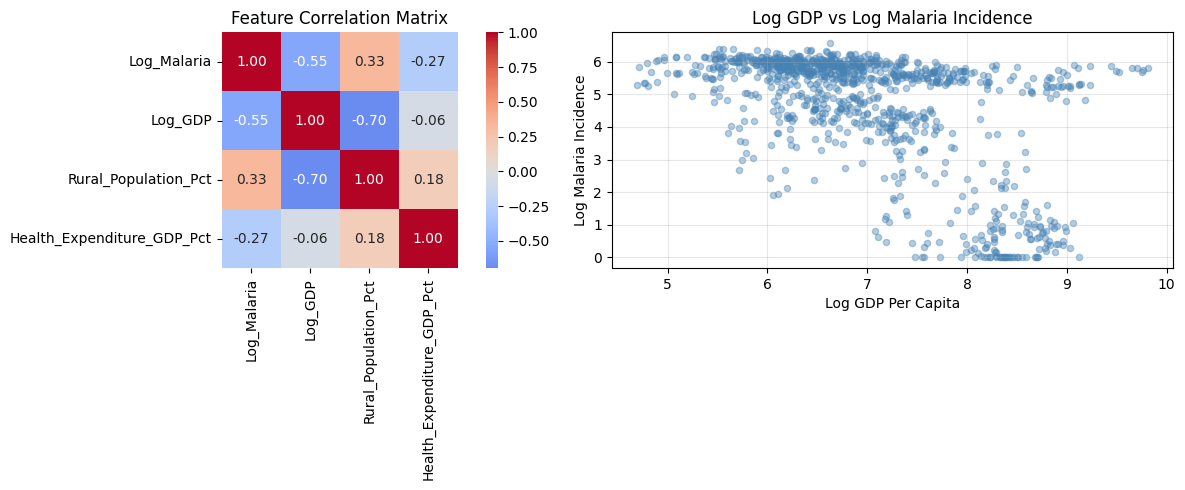

Correlations with Log Malaria:
Log_GDP                      -0.548388
Health_Expenditure_GDP_Pct   -0.272347
Rural_Population_Pct          0.326743
Log_Malaria                   1.000000
Name: Log_Malaria, dtype: float64


In [5]:
df_model = df_clean.copy()
df_model['Log_Malaria'] = np.log1p(df_model['Malaria_Incidence'])
df_model['Log_GDP'] = np.log(df_model['GDP_Per_Capita'])

corr_cols = ['Log_Malaria','Log_GDP','Rural_Population_Pct','Health_Expenditure_GDP_Pct']
corr = df_model[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix')

axes[1].scatter(df_model['Log_GDP'], df_model['Log_Malaria'],
                alpha=0.4, color='steelblue', s=20)
axes[1].set_xlabel('Log GDP Per Capita')
axes[1].set_ylabel('Log Malaria Incidence')
axes[1].set_title('Log GDP vs Log Malaria Incidence')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlations with Log Malaria:")
print(corr['Log_Malaria'].sort_values())

## 5. Model Training & Comparison

In [6]:
features = ['Log_GDP', 'Rural_Population_Pct', 'Health_Expenditure_GDP_Pct']
target = 'Log_Malaria'

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    if name == 'Random Forest':
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'R2': r2, 'predictions': y_pred}
    print(f"{name}: R² = {r2:.3f} | RMSE = {rmse:.3f}")

Linear Regression: R² = 0.474 | RMSE = 1.313
Ridge Regression: R² = 0.474 | RMSE = 1.313
Random Forest: R² = 0.789 | RMSE = 0.833


## 6. Hyperparameter Tuning — Random Forest

In [7]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=5, scoring='r2',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"Best params: {grid_search.best_params_}")
print(f"Tuned R²:    {r2_best:.3f}")
print(f"Tuned RMSE:  {rmse_best:.3f}")

# Note: tuning produced negligible improvement — base model was well configured

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Tuned R²:    0.785
Tuned RMSE:  0.840


## 7. Model Evaluation Visualizations

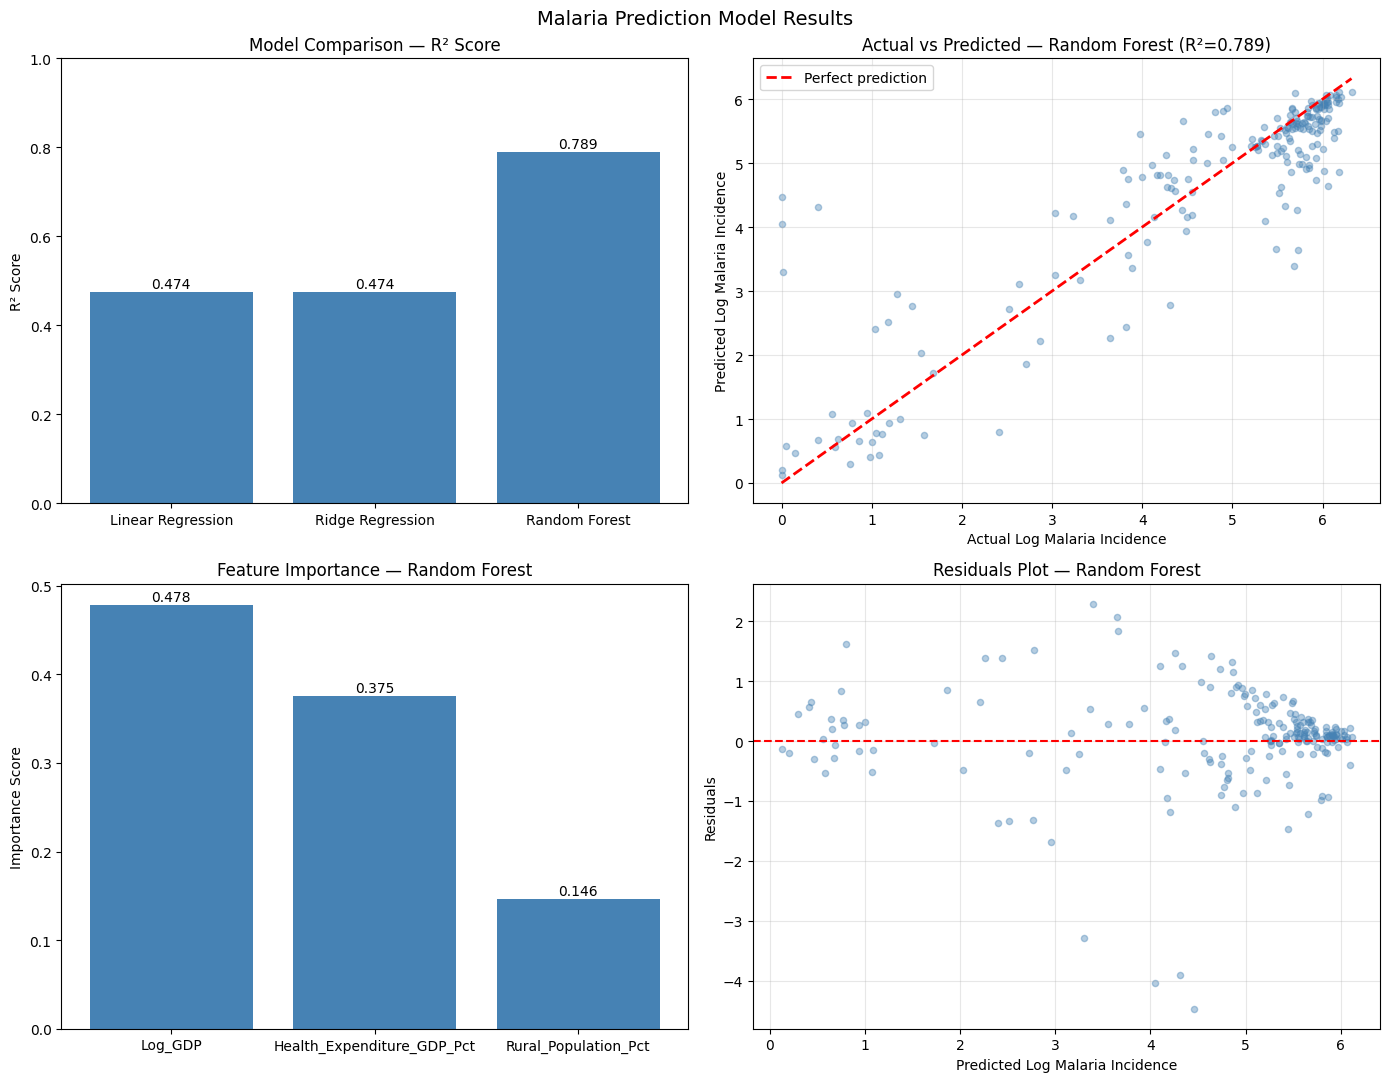

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

model_names = list(results.keys())
r2_scores = [results[m]['R2'] for m in model_names]

axes[0,0].bar(model_names, r2_scores, color='steelblue')
axes[0,0].set_title('Model Comparison — R² Score')
axes[0,0].set_ylabel('R² Score')
axes[0,0].set_ylim(0, 1)
for i, v in enumerate(r2_scores):
    axes[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

axes[0,1].scatter(y_test, results['Random Forest']['predictions'],
                  alpha=0.4, color='steelblue', s=20)
axes[0,1].plot([y_test.min(), y_test.max()],
               [y_test.min(), y_test.max()], 'r--', linewidth=2,
               label='Perfect prediction')
axes[0,1].set_xlabel('Actual Log Malaria Incidence')
axes[0,1].set_ylabel('Predicted Log Malaria Incidence')
axes[0,1].set_title('Actual vs Predicted — Random Forest (R²=0.789)')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

importances = pd.Series(
    best_rf.feature_importances_, index=features
).sort_values(ascending=False)
axes[1,0].bar(importances.index, importances.values, color='steelblue')
axes[1,0].set_title('Feature Importance — Random Forest')
axes[1,0].set_ylabel('Importance Score')
for i, v in enumerate(importances.values):
    axes[1,0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

residuals = y_test - results['Random Forest']['predictions']
axes[1,1].scatter(results['Random Forest']['predictions'],
                  residuals, alpha=0.4, color='steelblue', s=20)
axes[1,1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1,1].set_xlabel('Predicted Log Malaria Incidence')
axes[1,1].set_ylabel('Residuals')
axes[1,1].set_title('Residuals Plot — Random Forest')
axes[1,1].grid(alpha=0.3)

plt.suptitle('Malaria Prediction Model Results', fontsize=14)
plt.tight_layout()
plt.savefig('chart3_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Random Forest (R²=0.789) significantly outperforms linear models (R²=0.474).
# GDP per capita is the strongest predictor. Health expenditure shows stronger
# non-linear interactions than its linear correlation suggested.

## 8. Country-Level Predictions vs Actuals (2023)

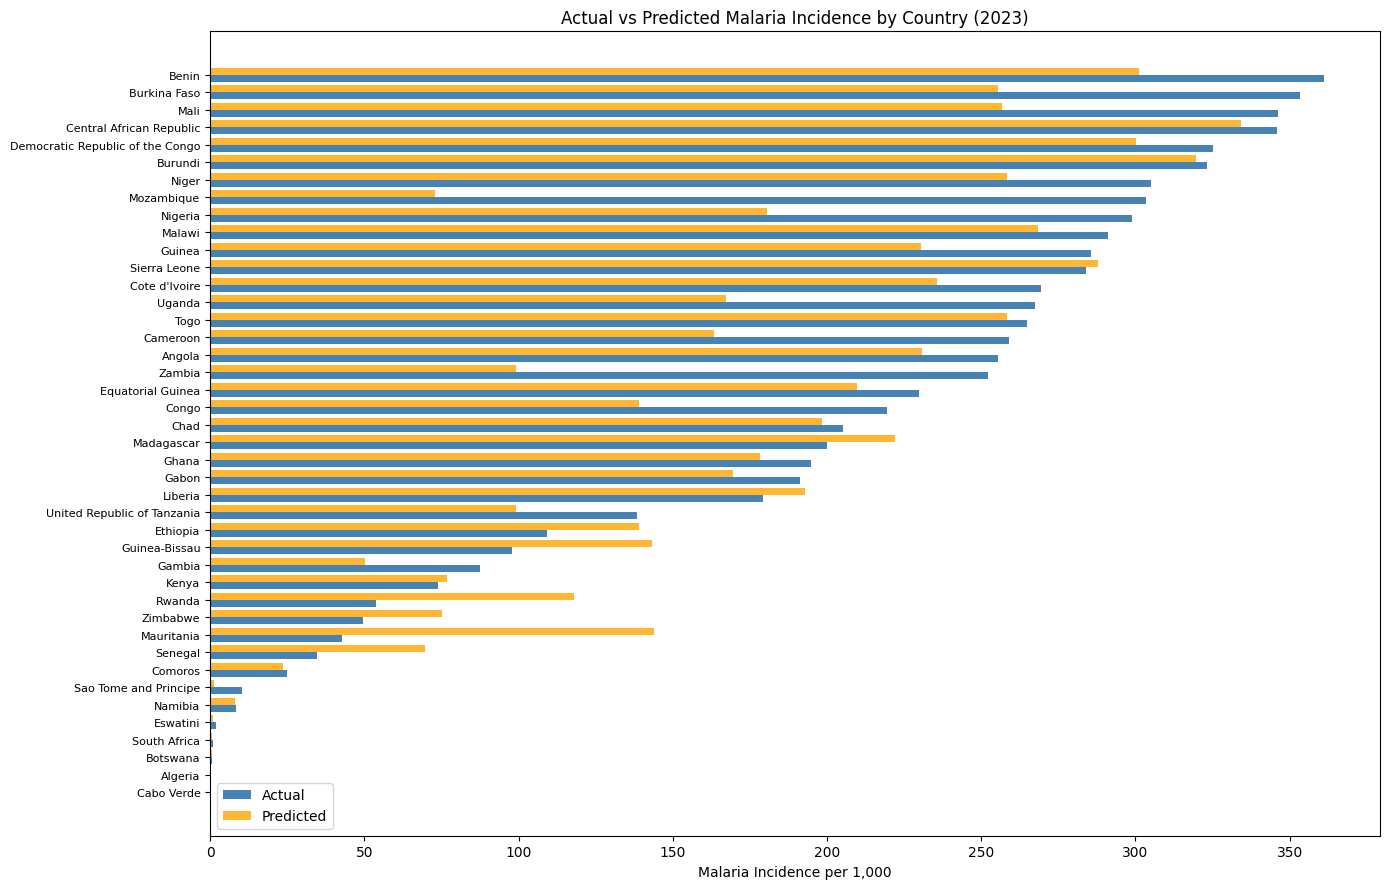

In [9]:
df_2023 = df_model[df_model['Year'] == 2023].copy()
X_2023 = df_2023[features]
df_2023['Predicted_Log'] = best_rf.predict(X_2023)
df_2023['Predicted_Incidence'] = np.expm1(df_2023['Predicted_Log'])
df_2023 = df_2023.sort_values('Malaria_Incidence', ascending=True)

plt.figure(figsize=(14, 9))
x = range(len(df_2023))
plt.barh([i - 0.2 for i in x], df_2023['Malaria_Incidence'],
         height=0.4, color='steelblue', label='Actual')
plt.barh([i + 0.2 for i in x], df_2023['Predicted_Incidence'],
         height=0.4, color='orange', alpha=0.8, label='Predicted')
plt.yticks(list(x), df_2023['Country_Name'], fontsize=8)
plt.xlabel('Malaria Incidence per 1,000')
plt.title('Actual vs Predicted Malaria Incidence by Country (2023)')
plt.legend()
plt.tight_layout()
plt.savefig('chart4_predictions_2023.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Niger's actual burden far exceeds predictions — extreme seasonality
# and weak vector control not captured by GDP or spending alone.
# Rwanda and Ghana both outperform predictions — community health programs
# deliver outcomes beyond what socioeconomic features alone would suggest.

## 9. Conclusions

### Model Performance

| Model | R² | RMSE |
|---|---|---|
| Linear Regression | 0.474 | 1.313 |
| Ridge Regression | 0.474 | 1.313 |
| **Random Forest (Tuned)** | **0.785** | **0.840** |

### Key Findings

| Finding | Implication |
|---|---|
| **Africa malaria incidence fell 40% since 2000** | Bed nets, artemisinin treatment, and donor funding are working |
| **GDP per capita is strongest predictor** | Poverty is the primary structural driver of malaria risk |
| **Random Forest outperforms linear models** | Non-linear socioeconomic interactions drive malaria burden |
| **Niger underpredicted, Rwanda overpredicted** | CHW programs and seasonality not captured by 3 features |
| **Health expenditure matters non-linearly** | How you spend matters more than how much you spend |

### Limitations
- Only 3 features — climate variables (rainfall, temperature) would significantly improve performance
- No spatial autocorrelation — neighboring countries share disease dynamics
- Annual data misses seasonal malaria peaks

---

**Data Sources:** WHO GHO API | World Bank API  
**Analysis by:** Afriyie Karikari Bempah, PharmD | [LinkedIn](https://linkedin.com/in/afriyiekarikaribempah) | [GitHub](https://github.com/akbempah1)